# Figure S7 — External-validation AUROC vs number of selected TSSs

Generalization of CRIS-trained data-driven models to the Jiang cohort as a
function of the number of selected TSSs (k). For each k the model deployed is
the best configuration by training-CV AUC; each point is annotated with the
fragmentomic feature that configuration uses. Performance plateaus and does
not decrease as k grows — the high-k gains in Fig 4 are not training-cohort
overfitting.

**Source data**: `data/figS7_auc_vs_k.csv` (written by `export/export_fig5.py`
from the comprehensive external-validation summary). No pickles, no cluster
paths, no network. Run top to bottom from `src/figures/`.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

s7 = pd.read_csv("data/figS7_auc_vs_k.csv").sort_values("n_genes")
display(s7)

,n_genes,external_auc,training_cv_auc,feature,classifier
0,10,0.523045,0.771508,fslr,Random Forest
1,25,0.486502,0.774150,fslr,Random Forest
2,50,0.569218,0.748469,griffin_diff,Support Vector Machine
3,100,0.645350,0.801338,griffin_diff,Multi-Layer Perceptron
4,250,0.600905,0.850079,griffin_diff,Support Vector Machine
5,500,0.652757,0.896327,griffin_diff,Support Vector Machine
6,1000,0.653663,0.916293,griffin_diff,Support Vector Machine
7,1500,0.663333,0.918322,griffin_diff,Support Vector Machine
8,2500,0.666255,0.921916,griffin_diff,Support Vector Machine
9,5000,0.668724,0.921553,griffin_diff,Logistic Regression


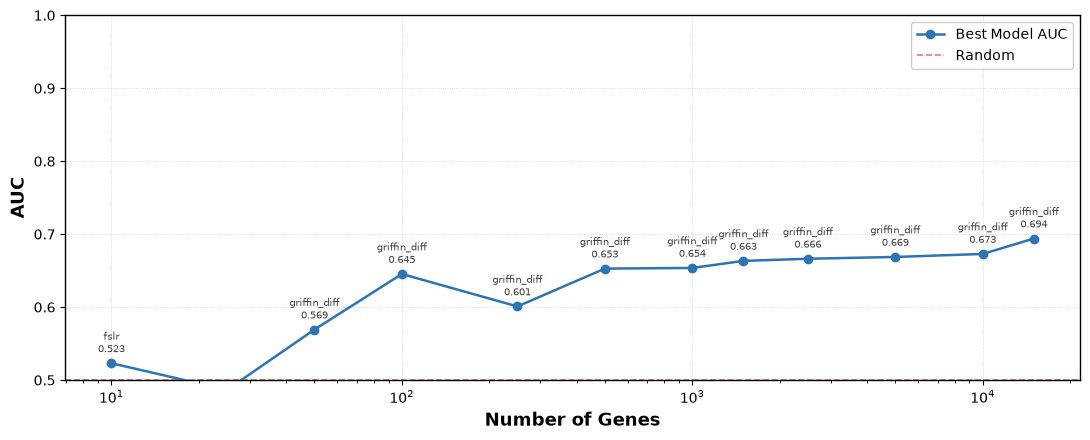

In [2]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(s7["n_genes"], s7["external_auc"], "o-", color="#2E74B5", linewidth=1.8,
        markersize=6, label="Best Model AUC", zorder=3)
ax.axhline(0.5, color="#E15759", linestyle="--", linewidth=1.2, alpha=0.8,
           label="Random")

for _, r in s7.iterrows():
    ax.annotate(f"{r['feature']}\n{r['external_auc']:.3f}",
                (r["n_genes"], r["external_auc"]),
                textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=7.5, color="0.25")

ax.set_xscale("log")
ax.set_ylim(0.5, 1.0)  # matches the submitted panel; the k=25 point (0.487) sits below the axis
ax.set_xlabel("Number of Genes", fontsize=13, fontweight="bold")
ax.set_ylabel("AUC", fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=10, frameon=True, framealpha=0.92)
ax.grid(True, which="major", linestyle=":", linewidth=0.6, color="0.75", alpha=0.7)
ax.set_axisbelow(True)
for sp in ax.spines.values():
    sp.set_visible(True); sp.set_linewidth(1.0); sp.set_color("black")

plt.tight_layout()
os.makedirs("output", exist_ok=True)
fig.savefig("output/figS7.png", dpi=300, bbox_inches="tight")
fig.savefig("output/figS7.pdf", bbox_inches="tight")
plt.show()

## Check against the manuscript

The submitted S7 shows AUC rising from ~0.52 (k=10, fslr) through
griffin_diff configurations to 0.694 at k = 14,224, without any decline at
high k.

In [3]:
print(s7.to_string(index=False))
last = s7.iloc[-1]
print(f"\nfinal point: k={int(last['n_genes'])}, feature={last['feature']}, "
      f"external AUC={last['external_auc']:.3f}   (manuscript: griffin_diff 0.694)")
assert s7["external_auc"].iloc[-1] >= s7["external_auc"].iloc[0], \
    "expected no net decline from smallest to largest k"

 n_genes  external_auc  training_cv_auc      feature             classifier
      10      0.523045         0.771508         fslr          Random Forest
      25      0.486502         0.774150         fslr          Random Forest
      50      0.569218         0.748469 griffin_diff Support Vector Machine
     100      0.645350         0.801338 griffin_diff Multi-Layer Perceptron
     250      0.600905         0.850079 griffin_diff Support Vector Machine
     500      0.652757         0.896327 griffin_diff Support Vector Machine
    1000      0.653663         0.916293 griffin_diff Support Vector Machine
    1500      0.663333         0.918322 griffin_diff Support Vector Machine
    2500      0.666255         0.921916 griffin_diff Support Vector Machine
    5000      0.668724         0.921553 griffin_diff    Logistic Regression
   10000      0.672840         0.945374 griffin_diff    Logistic Regression
   15000      0.693992         0.946769 griffin_diff    Logistic Regression

final point